# Reconhecimento de Dígitos Manuscritos

Este trabalho é referente à disciplina de Aprendizado de Máquina (MS571/MT571), ministrado no segundo semestre de 2026 pelo Prof.° Dr. João Florindo.

Autores: Gustavo Oliveira Nunes, João Luís Motta Martinez, Luisa de Melo Carneiro e Maria Eduarda Villéla Silva.

**Arquivos utilizados:**

* `imageMNIST.csv` — imagens da base MNIST linearizadas em vetores;
* `labelMNIST.csv` — dígitos correspondentes a cada imagem.

**Base de dados:** `MNIST`.


## Parte I — Redes Neurais

Este módulo implementa uma rede neural regularizada para classificação de dígitos manuscritos da base `MNIST`, incluindo:

* Linearização das imagens 20 × 20 em vetores de 400 elementos;
* Rede neural com uma camada escondida, inicialmente com 25 neurônios;
* Cálculo da porcentagem de imagens classificadas corretamente;
* Visualização das imagens classificadas incorretamente, com seus respectivos rótulos verdadeiro e predito;
* Implementação do **backpropagation** para treinamento da rede;
* Implementação do algoritmo de **checagem numérica do gradiente**;
* Treinamento da rede utilizando **gradiente conjugado**;
* Suporte a diferentes números de exemplos, classes, camadas e neurônios;
* Visualização da representação de cada unidade escondida como uma imagem 20 × 20;
* Normalização das representações entre 0 e 1 para facilitar a visualização.

### Parte II — Seleção de Modelo

Esta etapa implementa procedimentos para avaliação e seleção do modelo, incluindo:

* Divisão dos dados em conjuntos de **treino, validação e teste**;
* Cálculo dos erros de treino, validação e teste;
* Geração da **curva de aprendizado**, relacionando o erro ao tamanho do conjunto de treinamento;
* Busca automatizada do valor ótimo do parâmetro de regularização λ;
* Avaliação de diferentes valores de λ;
* Visualização do erro de validação em função de λ;
* Cálculo do erro de teste utilizando o valor ótimo de λ encontrado.

In [1]:
import os
import urllib.request

path = "./"

github_files = {
    "imageMNIST.csv": "https://raw.githubusercontent.com/mdudavillela/mnist-digit-recognition/refs/heads/main/imageMNIST.csv",
    "labelMNIST.csv": "https://raw.githubusercontent.com/mdudavillela/mnist-digit-recognition/refs/heads/main/labelMNIST.csv",
}

for filename, url in github_files.items():
    filepath = os.path.join(path, filename)
    if not os.path.exists(filepath):
        print(f"Baixando {filename}...")
        urllib.request.urlretrieve(url, filepath)
    else:
        print(f"{filename} já está na pasta local, usando o arquivo existente.")

Baixando imageMNIST.csv...
Baixando labelMNIST.csv...


In [2]:
# Bibliotecas
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
from scipy.optimize import minimize

In [3]:
X = np.loadtxt(path + "imageMNIST.csv",delimiter=",",quotechar='"',converters=lambda value: float(value.replace(",", ".")),encoding="utf-8")
y = np.loadtxt(path + "labelMNIST.csv", dtype=int).ravel()
y[y == 10] = 0

classes = np.unique(y)
class_to_index = {label: i for i, label in enumerate(classes)}
y_index = np.array([class_to_index[label] for label in y])

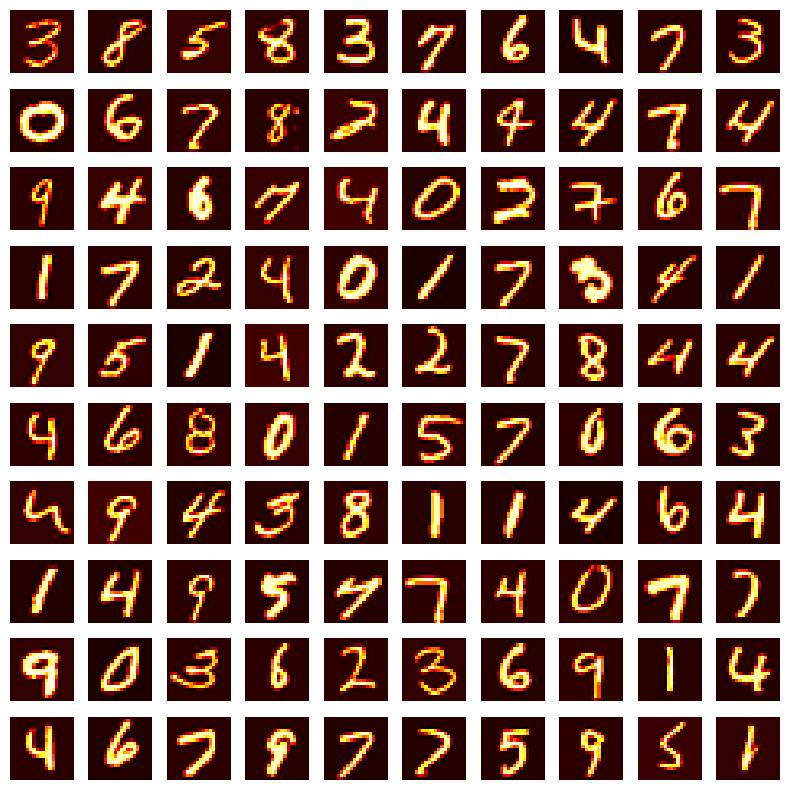

In [4]:
fig,axis = plt.subplots(10, 10, figsize=(8, 8))
for i in range(10):
    for j in range(10):
        axis[i,j].imshow(X[np.random.randint(0, X.shape[0]), :].reshape(20, 20, order="F"),cmap="hot")
        axis[i,j].axis("off")
plt.tight_layout()
plt.show()

### Ativação, custo e backpropagation

As operações da rede são implementadas diretamente com NumPy. A multiplicação matricial apenas agrupa os cálculos de todos os exemplos.

### Implementação numericamente estável da sigmoide

A função sigmoide é definida por:

$$
\sigma(z)=\frac{1}{1+e^{-z}}.
$$

Quando $z$ é muito negativo, o termo $e^{-z}$ torna-se muito grande e pode ultrapassar o limite numérico do computador, causando *overflow*. Para evitar isso, utilizamos duas expressões matematicamente equivalentes, dependendo do sinal de $z$.

Para $z \geq 0$, usamos diretamente a definição original:

$$
\sigma(z)=\frac{1}{1+e^{-z}}.
$$

Nesse caso, $-z \leq 0$, portanto $e^{-z}$ fica entre 0 e 1 e não provoca overflow.

Para $z < 0$, multiplicamos o numerador e o denominador por $e^z$:

$$
\sigma(z)
=\frac{1}{1+e^{-z}}
=\frac{e^z}{e^z+e^{-z}e^z}
=\frac{e^z}{1+e^z}.
$$

Como $z < 0$, o termo $e^z$ também fica entre 0 e 1. Assim, implementamos:

$$
\sigma(z)=
\begin{cases}
\dfrac{1}{1+e^{-z}}, & z \geq 0, \\[6pt]
\dfrac{e^z}{1+e^z}, & z < 0.
\end{cases}
$$

No código, `np.asarray(z, dtype=float)` transforma a entrada em um array de números de ponto flutuante. `np.zeros_like(z)` cria o array de resultados com o mesmo formato da entrada.

A máscara `positive = z >= 0` identifica os elementos não negativos, enquanto `~positive` identifica os negativos. Cada expressão é calculada somente para os elementos correspondentes.

Essa implementação mantém a mesma função matemática, mas evita calcular exponenciais de números positivos muito grandes. Para valores extremos, a exponencial pode ser arredondada para zero, fazendo a sigmoide retornar 0 ou 1, de acordo com seus limites.

In [5]:
def sigmoid(z):
    z = np.asarray(z, dtype=float)
    result = np.zeros_like(z)
    positive = z >= 0
    result[positive] = 1/(1+np.exp(-z[positive]))
    exp_z = np.exp(z[~positive])
    result[~positive] = exp_z/(1+exp_z)
    return result

In [6]:
def sigmoidGradient(z):
    s = sigmoid(z)
    return s*(1-s)

In [7]:
def unpackTheta(theta,layer_sizes):
    weights = []
    start = 0
    for i in range(len(layer_sizes)-1):
        size = layer_sizes[i+1]*(layer_sizes[i]+1)
        weights.append(theta[start:start+size].reshape(layer_sizes[i+1],layer_sizes[i]+1))
        start += size
    if start != len(theta):
        raise ValueError("O tamanho de theta não corresponde às camadas.")
    return weights


def computeCost(X,y,theta,layer_sizes,Lambda):
    weights = unpackTheta(theta,layer_sizes)
    m = X.shape[0]
    y = np.asarray(y).ravel()
    num_labels = layer_sizes[-1]
    Y = np.zeros((m,num_labels))
    for i in range(m):
        Y[i,y[i]] = 1

    activations = [X]
    z_values = []
    for W in weights:
        a_bias = np.hstack((np.ones((m,1)),activations[-1]))
        z = a_bias @ W.T
        z_values.append(z)
        activations.append(sigmoid(z))

    z = z_values[-1]
    loss = np.maximum(z,0) - Y*z + np.log1p(np.exp(-np.abs(z)))
    cost = np.sum(loss)/m
    reg = 0
    for W in weights:
        reg += np.sum(W[:,1:]**2)
    reg_J = cost + Lambda/(2*m)*reg

    gradients = [None]*len(weights)
    delta = activations[-1] - Y
    for layer in range(len(weights)-1,-1,-1):
        a_bias = np.hstack((np.ones((m,1)),activations[layer]))
        grad = delta.T @ a_bias/m
        grad[:,1:] += Lambda/m*weights[layer][:,1:]
        gradients[layer] = grad
        if layer > 0:
            delta = (delta @ weights[layer][:,1:])*sigmoidGradient(z_values[layer-1])

    gradient = np.concatenate([grad.ravel() for grad in gradients])
    return cost,reg_J,gradient

In [8]:
def randInitializeWeights(L_in,L_out):
    epi = (6**(1/2))/(L_in+L_out)**(1/2)
    W = np.random.rand(L_out,L_in+1)*(2*epi)-epi
    return W

In [9]:
def initializeTheta(layer_sizes):
    weights = []
    for i in range(len(layer_sizes)-1):
        weights.append(randInitializeWeights(layer_sizes[i],layer_sizes[i+1]).ravel())
    return np.concatenate(weights)


def gradientDescent(X,y,theta,alpha,nbr_iter,Lambda,layer_sizes):
    theta = theta.copy()
    J_history = []
    for i in range(nbr_iter):
        _,cost,gradient = computeCost(X,y,theta,layer_sizes,Lambda)
        J_history.append(cost)
        theta = theta - alpha*gradient
    J_history.append(computeCost(X,y,theta,layer_sizes,Lambda)[1])
    return theta,J_history

In [10]:
def prediction(X,theta,layer_sizes):
    weights = unpackTheta(theta,layer_sizes)
    a = X
    for W in weights:
        a = np.hstack((np.ones((X.shape[0],1)),a))
        a = sigmoid(a @ W.T)
    return np.argmax(a,axis=1)

### Treinamento por descida do gradiente

O treinamento utiliza o exemplo mostrado na Parte I.

In [11]:
%%time

input_layer_size = X.shape[1]
hidden_layer_sizes = [25]
num_labels = len(classes)
layer_sizes = [input_layer_size] + hidden_layer_sizes + [num_labels]
Lambda = 1
alpha = 1
nbr_iter = 500

np.random.seed(1)
initial_theta = initializeTheta(layer_sizes)
theta,J_history = gradientDescent(X,y_index,initial_theta,alpha,nbr_iter,Lambda,layer_sizes)

CPU times: user 54.4 s, sys: 5.4 s, total: 59.8 s
Wall time: 35.3 s


In [12]:
pred = classes[prediction(X,theta,layer_sizes)]
accuracy = np.sum(pred == y)/len(y)*100
print(f"Training Set Accuracy: {accuracy:.2f}%")

Training Set Accuracy: 93.74%


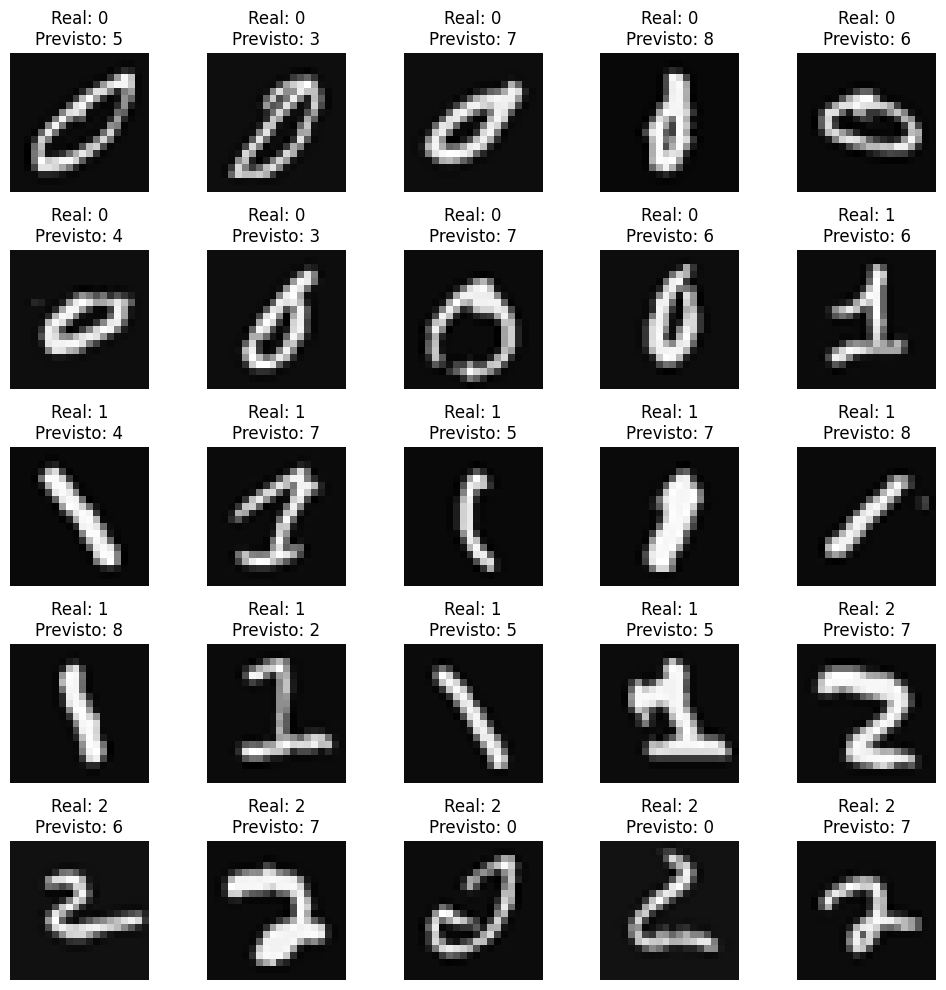

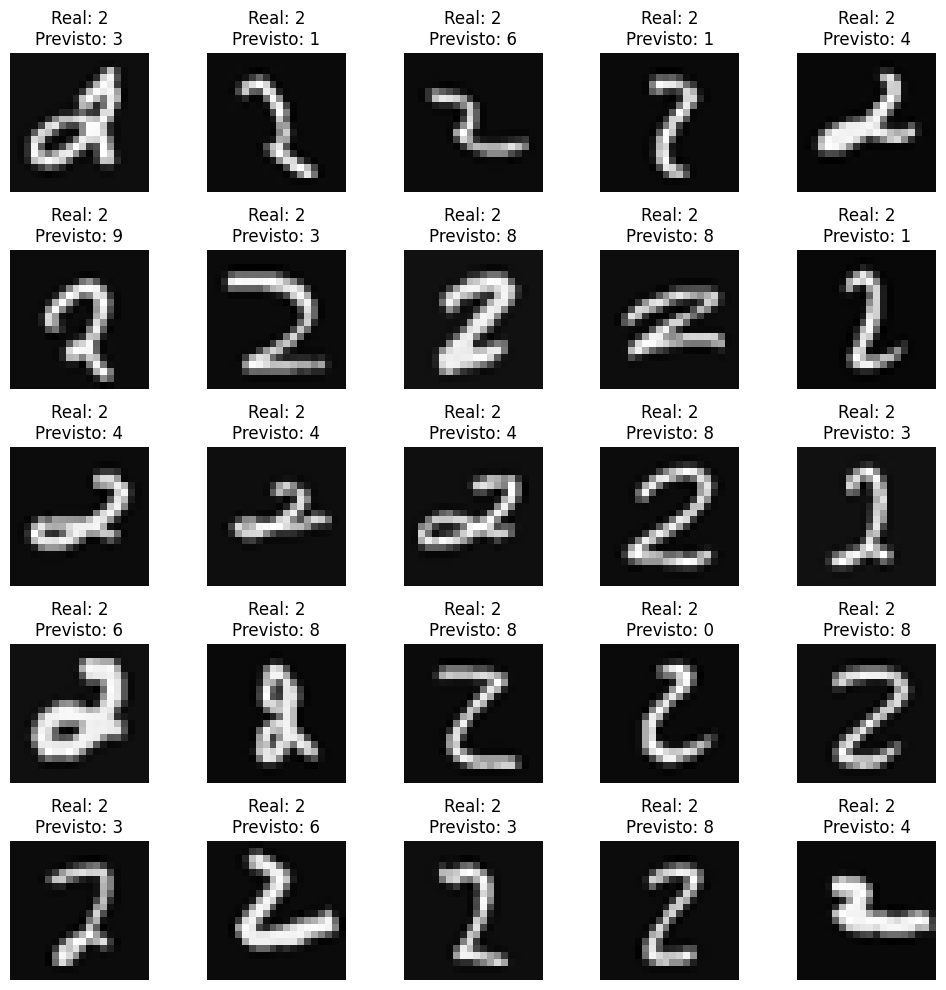

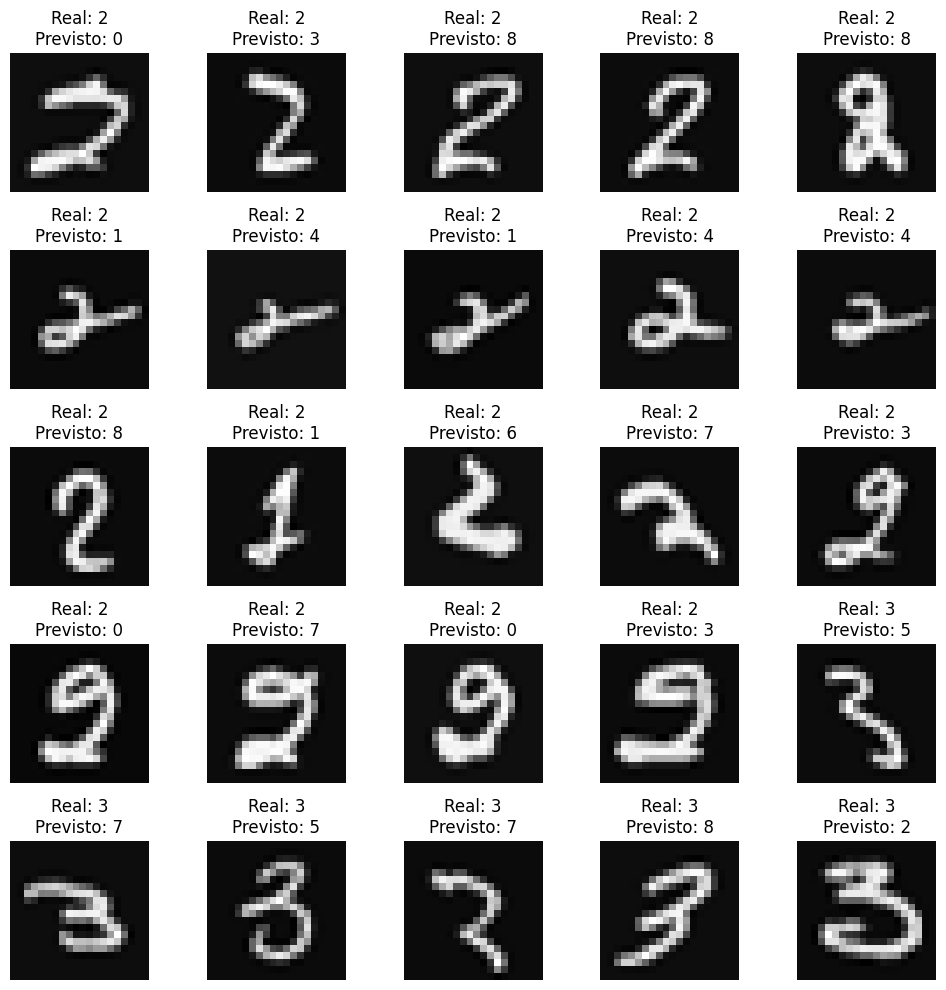

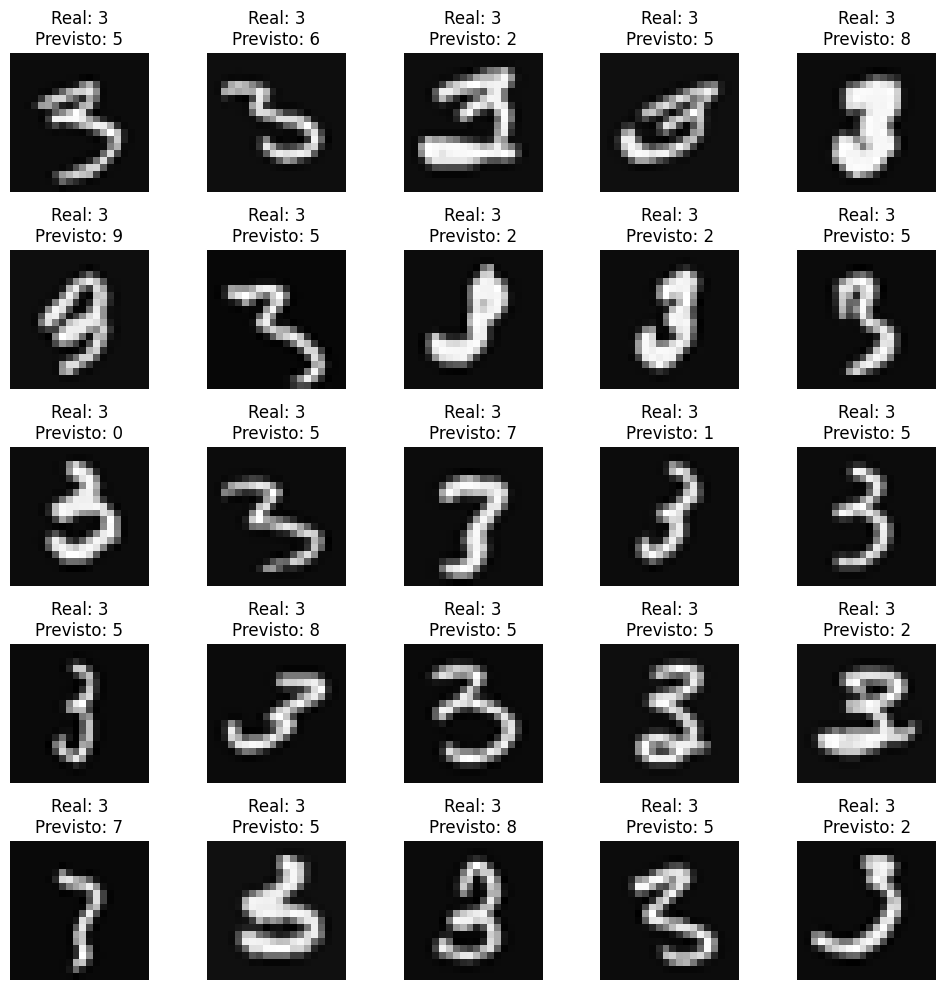

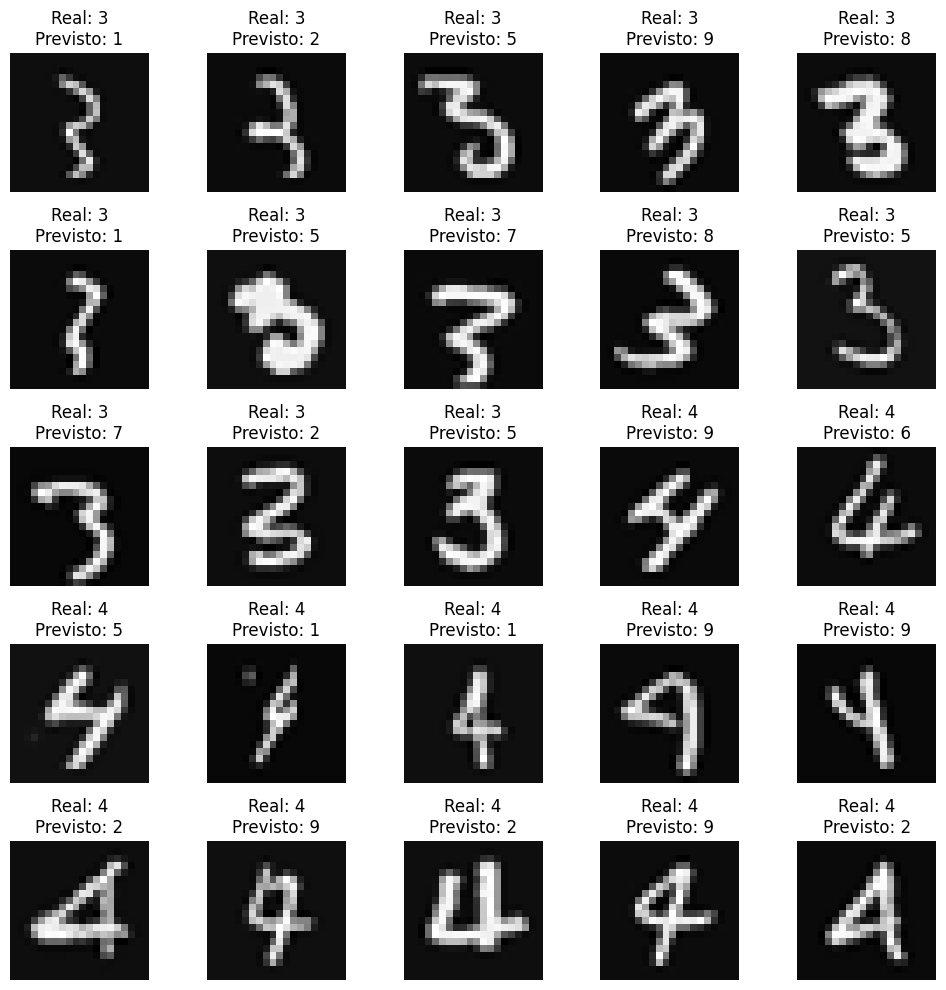

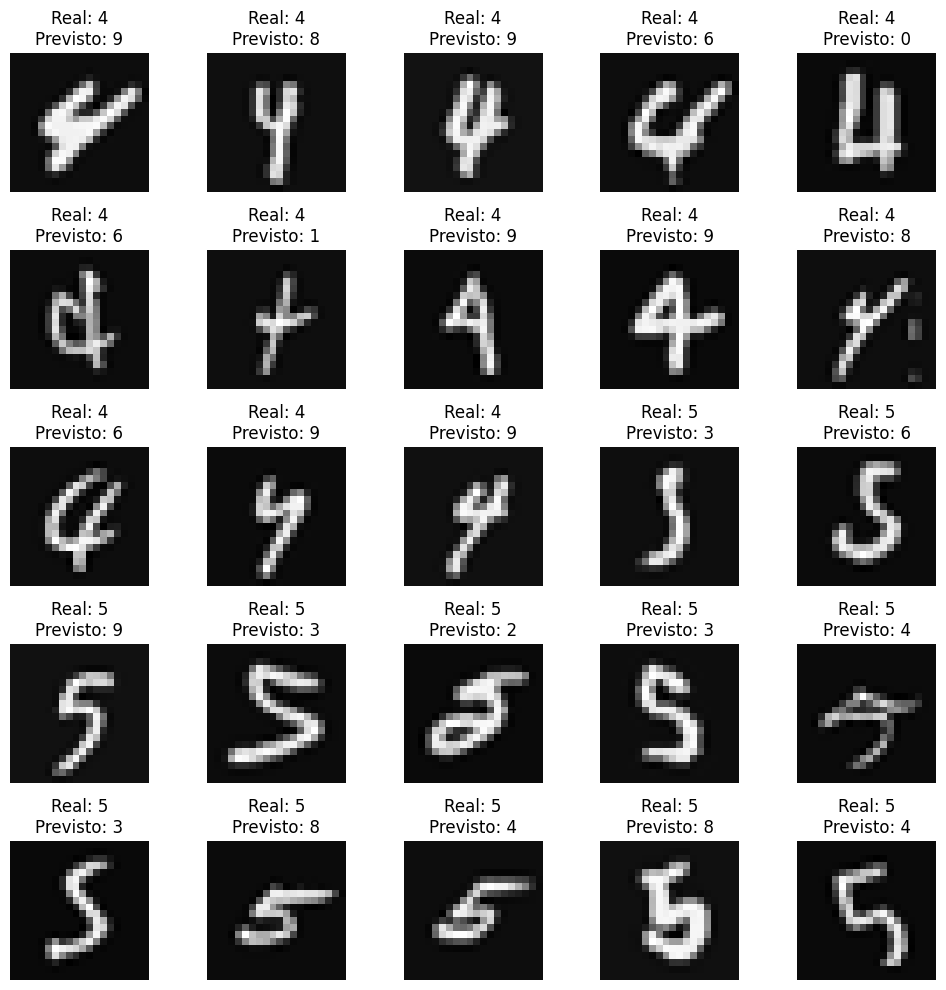

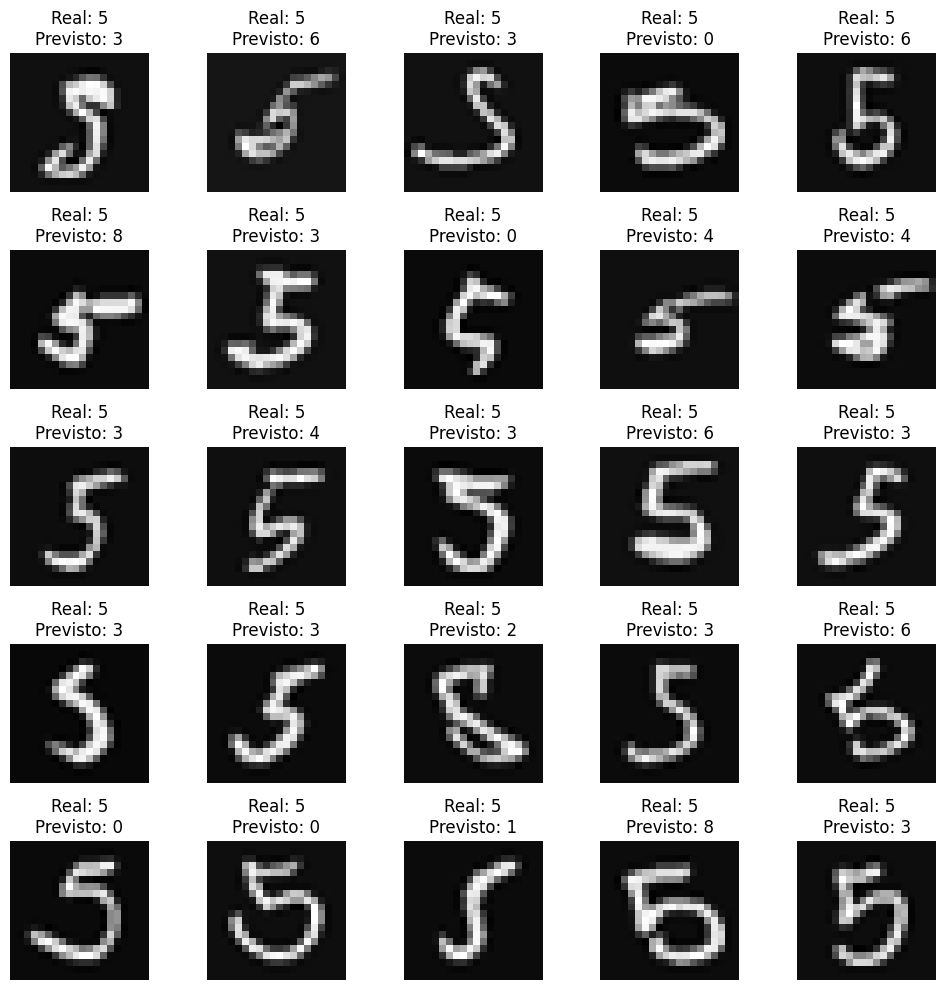

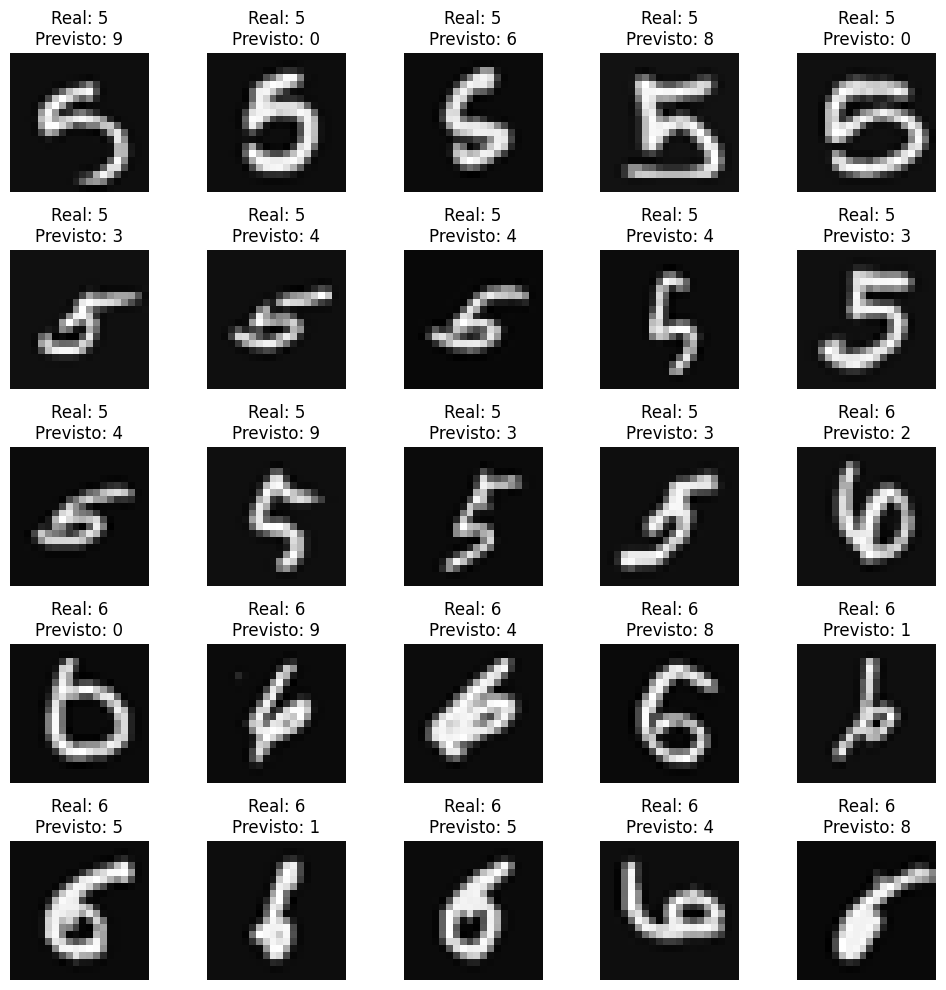

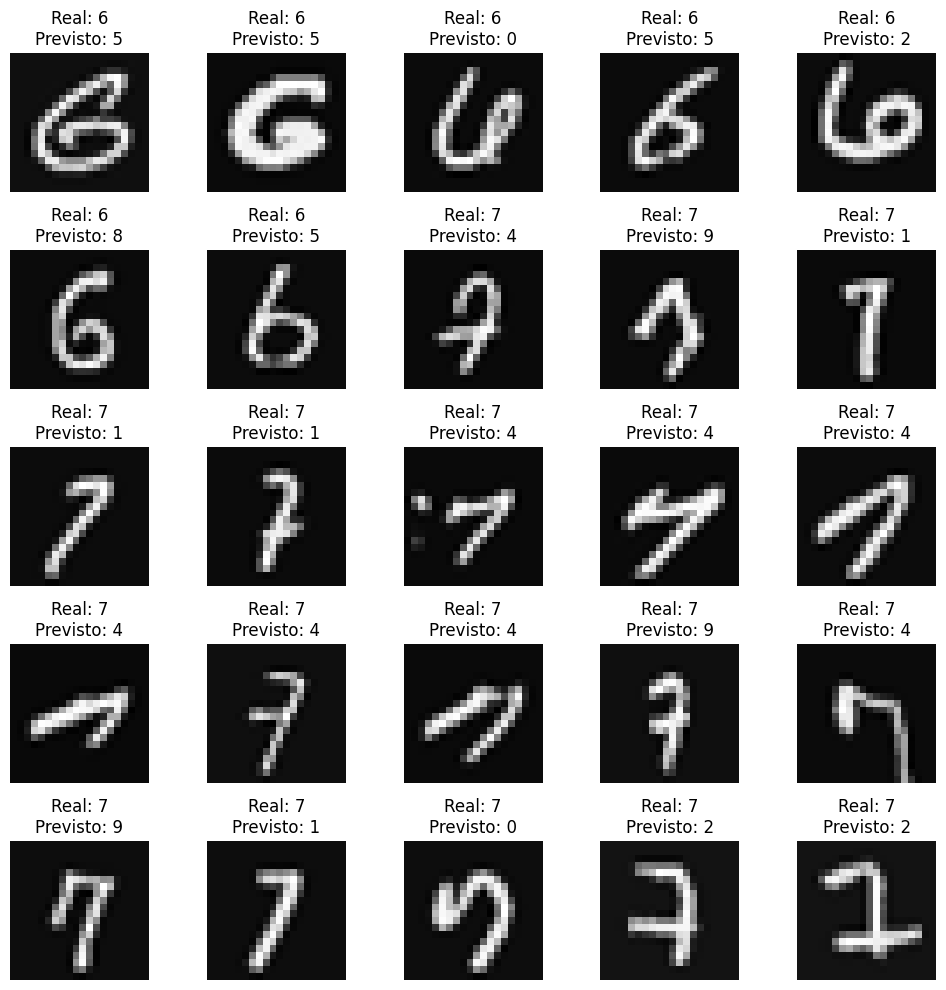

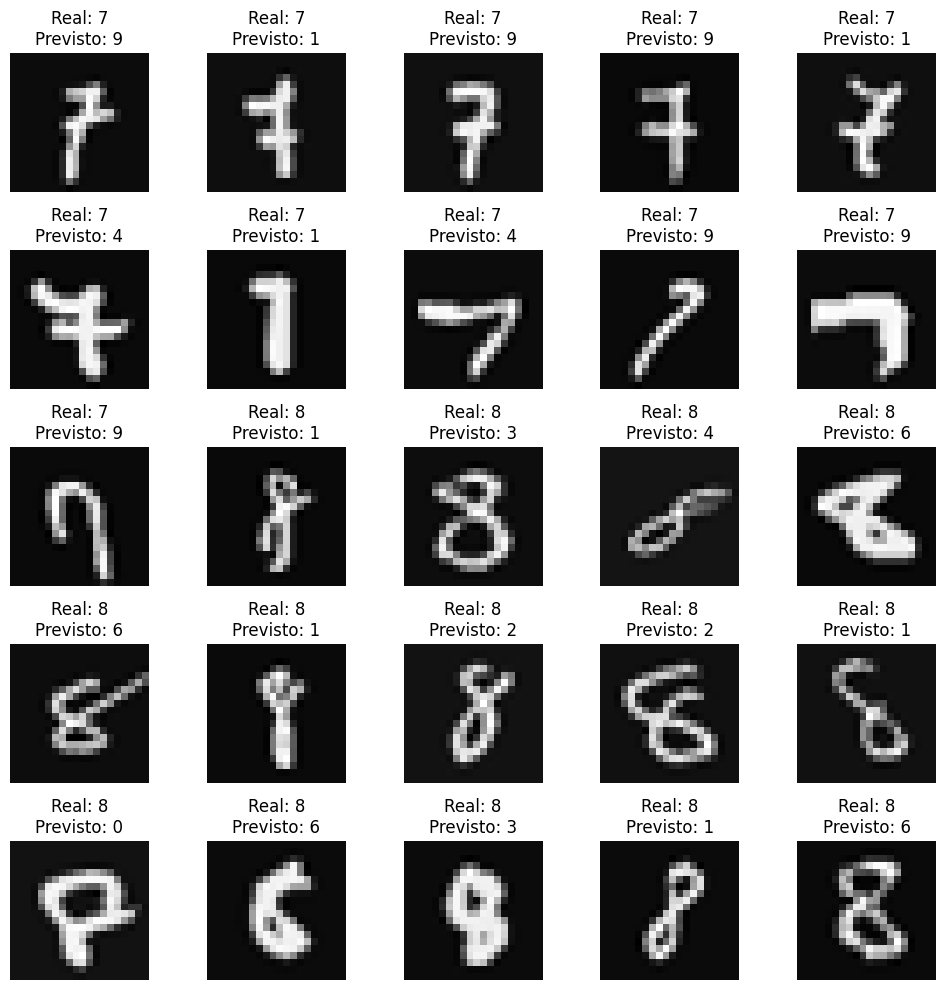

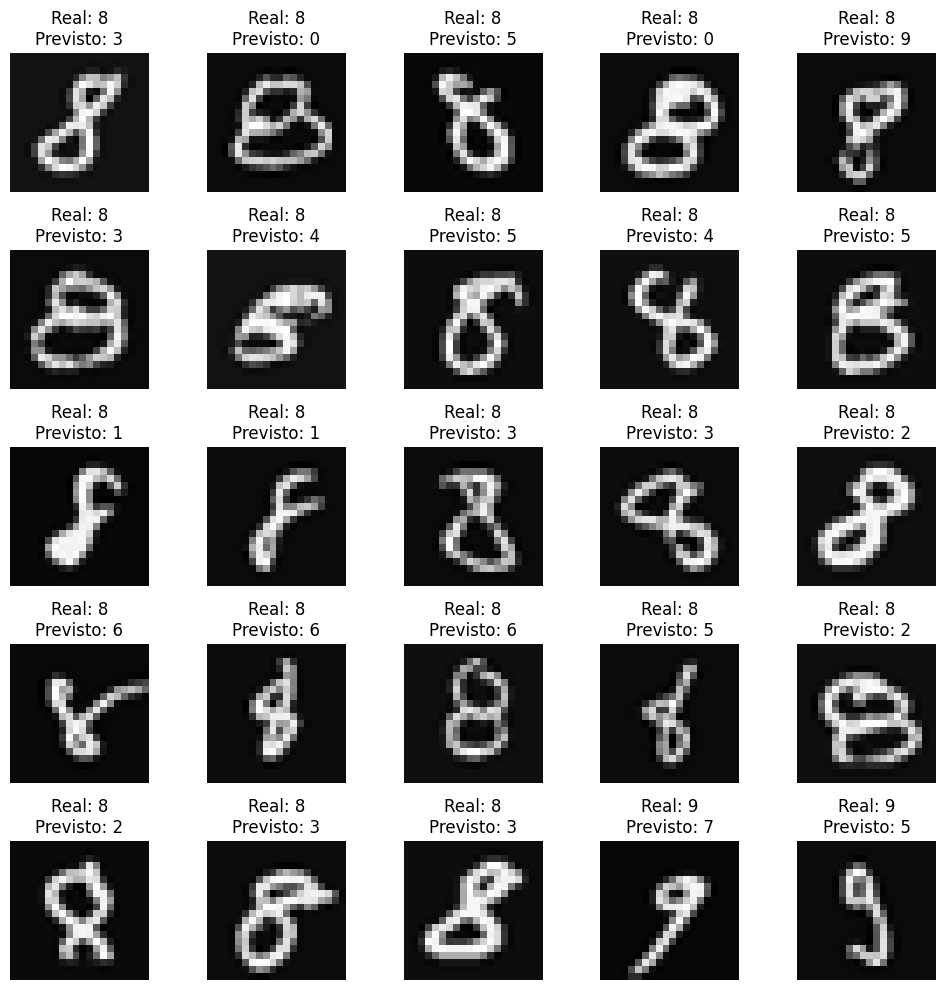

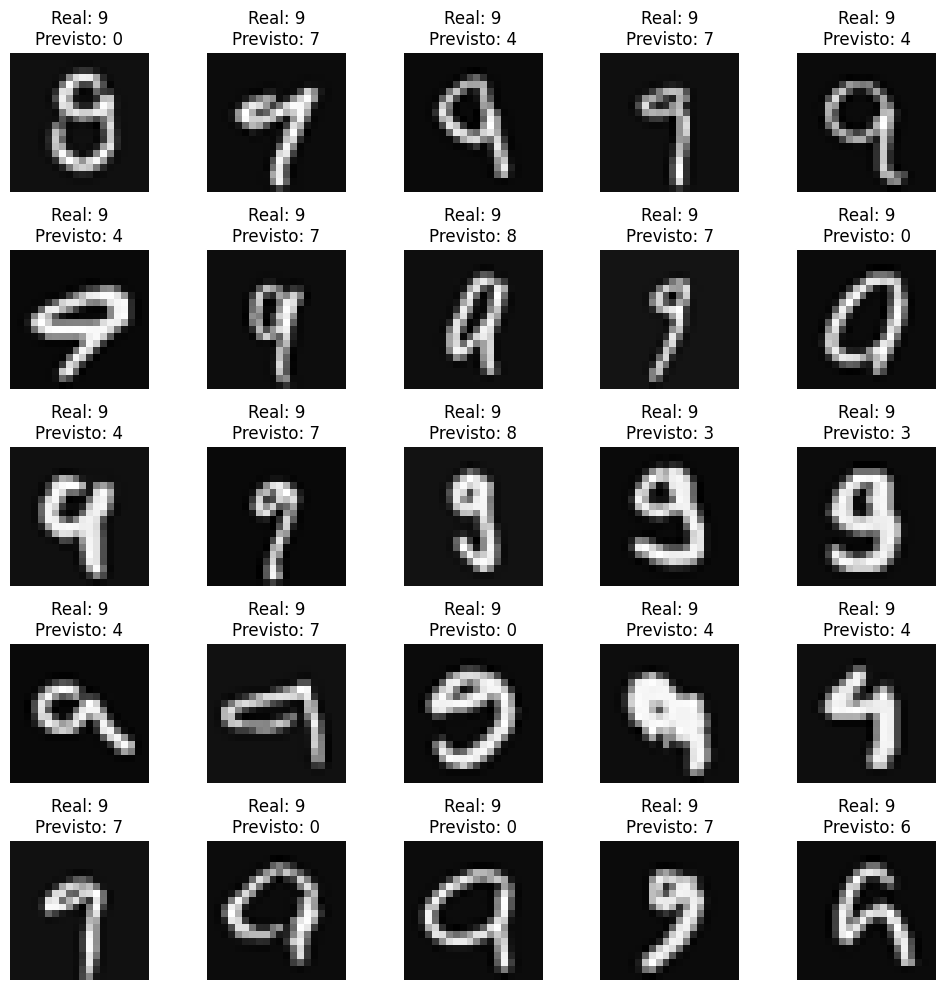

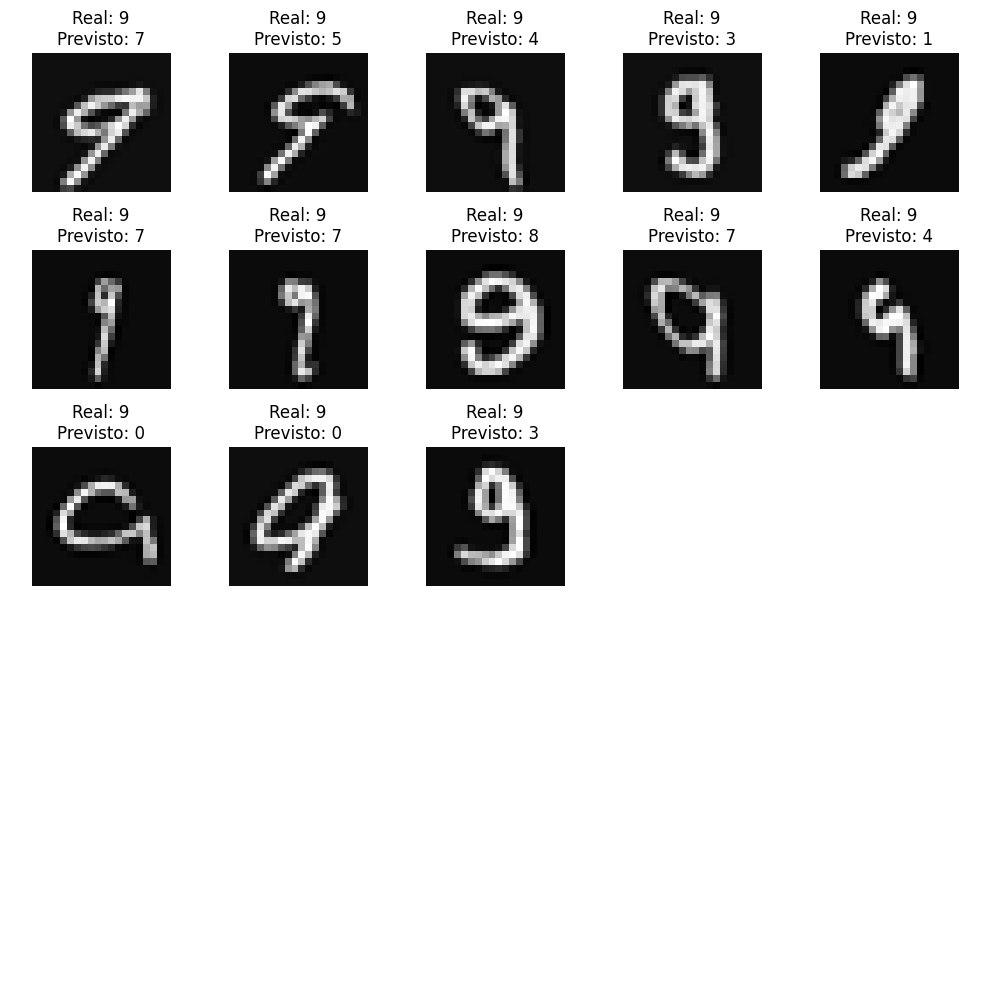

In [13]:
def showWrongImages(X,y,pred,n_show=None):
    wrong_idx = np.where(pred != y)[0]
    if n_show is not None:
        wrong_idx = wrong_idx[:n_show]
    if len(wrong_idx) == 0:
        print("Nenhuma imagem classificada incorretamente.")
        return

    for start in range(0,len(wrong_idx),25):
        fig,axes = plt.subplots(5,5,figsize=(10,10))
        axes = axes.ravel()
        for i in range(25):
            if start+i < len(wrong_idx):
                idx = wrong_idx[start+i]
                axes[i].imshow(X[idx].reshape(20,20,order="F"),cmap="gray")
                axes[i].set_title(f"Real: {y[idx]:g}\nPrevisto: {pred[idx]:g}")
            axes[i].axis("off")
        plt.tight_layout()
        plt.show()

showWrongImages(X,y,pred,n_show=None)

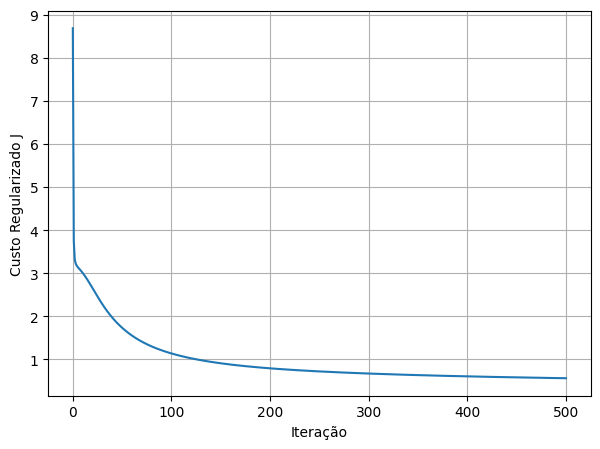

In [15]:
plt.figure(figsize=(7,5))

plt.plot(J_history)

plt.xlabel("Iteração")
plt.ylabel("Custo Regularizado J")

plt.grid()
plt.show()

### Checagem numérica do gradiente

A rede pequena permite comparar cada derivada do backpropagation com uma aproximação por diferenças centrais.

In [18]:
def gradient_checking(input_layer_size,hidden_layer_sizes,num_labels,m,Lambda,epsilon):
    rng = np.random.default_rng(1)
    if isinstance(hidden_layer_sizes,int):
        hidden_layer_sizes = [hidden_layer_sizes]
    layer_sizes_small = [input_layer_size] + hidden_layer_sizes + [num_labels]
    X_small = rng.random((m,input_layer_size))
    y_small = rng.integers(0,num_labels,size=m)
    n_params = 0
    for i in range(len(layer_sizes_small)-1):
        n_params += layer_sizes_small[i+1]*(layer_sizes_small[i]+1)
    theta_small = rng.random(n_params)*0.2-0.1

    grad_backprop = computeCost(X_small,y_small,theta_small,layer_sizes_small,Lambda)[2]
    grad_num = np.zeros(theta_small.shape)
    for i in range(len(theta_small)):
        theta_plus = theta_small.copy()
        theta_minus = theta_small.copy()
        theta_plus[i] += epsilon
        theta_minus[i] -= epsilon
        J_plus = computeCost(X_small,y_small,theta_plus,layer_sizes_small,Lambda)[1]
        J_minus = computeCost(X_small,y_small,theta_minus,layer_sizes_small,Lambda)[1]
        grad_num[i] = (J_plus-J_minus)/(2*epsilon)

    numerator = np.sqrt(np.sum((grad_num-grad_backprop)**2))
    denominator = np.sqrt(np.sum((grad_num+grad_backprop)**2))
    difference = numerator/max(denominator,1e-15)
    return grad_num,grad_backprop,difference

Lambda = 0 | Diferença Relativa: 1.11e-11
Lambda = 1 | Diferença Relativa: 1.14e-11


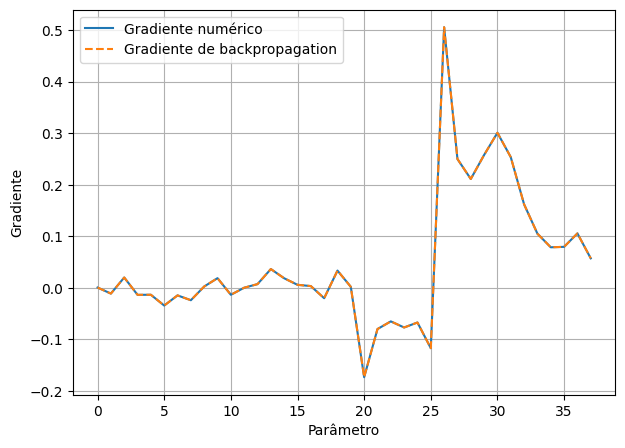

In [17]:
for Lambda_check in [0,1]:
    grad_num,grad_backprop,difference = gradient_checking(3,5,3,3,Lambda_check,1e-4)
    print(f"Lambda = {Lambda_check} | Diferença Relativa: {difference:.2e}")

plt.figure(figsize=(7,5))
plt.plot(grad_num,label="Gradiente numérico")
plt.plot(grad_backprop,"--",label="Gradiente de backpropagation")
plt.xlabel("Parâmetro")
plt.ylabel("Gradiente")
plt.legend()
plt.grid()
plt.show()

### Treinamento por gradiente conjugado

A função `minimize`, indicada no enunciado, recebe o custo regularizado e o gradiente calculado pelo nosso `backpropagation`. O método `CG` escolhe as direções de busca e os passos de atualização.

São comparados diferentes valores de λ e limites de iterações usando os mesmos pesos iniciais. `maxiter` é um limite: o algoritmo pode parar antes. As acurácias abaixo são de treino.

Lambda: 0 | Limite: 100 | Iterações: 100 | Custo: 0.044238 | Acurácia: 99.78%
Convergência: False | Maximum number of iterations has been exceeded.
Lambda: 0 | Limite: 400 | Iterações: 246 | Custo: 0.000520 | Acurácia: 100.00%
Convergência: True | Optimization terminated successfully.
Lambda: 1 | Limite: 100 | Iterações: 100 | Custo: 0.353668 | Acurácia: 98.38%
Convergência: False | Maximum number of iterations has been exceeded.
Lambda: 1 | Limite: 400 | Iterações: 400 | Custo: 0.312151 | Acurácia: 99.48%
Convergência: False | Maximum number of iterations has been exceeded.
Lambda: 10 | Limite: 100 | Iterações: 100 | Custo: 1.001030 | Acurácia: 94.00%
Convergência: False | Maximum number of iterations has been exceeded.
Lambda: 10 | Limite: 400 | Iterações: 400 | Custo: 0.986729 | Acurácia: 94.22%
Convergência: False | Maximum number of iterations has been exceeded.


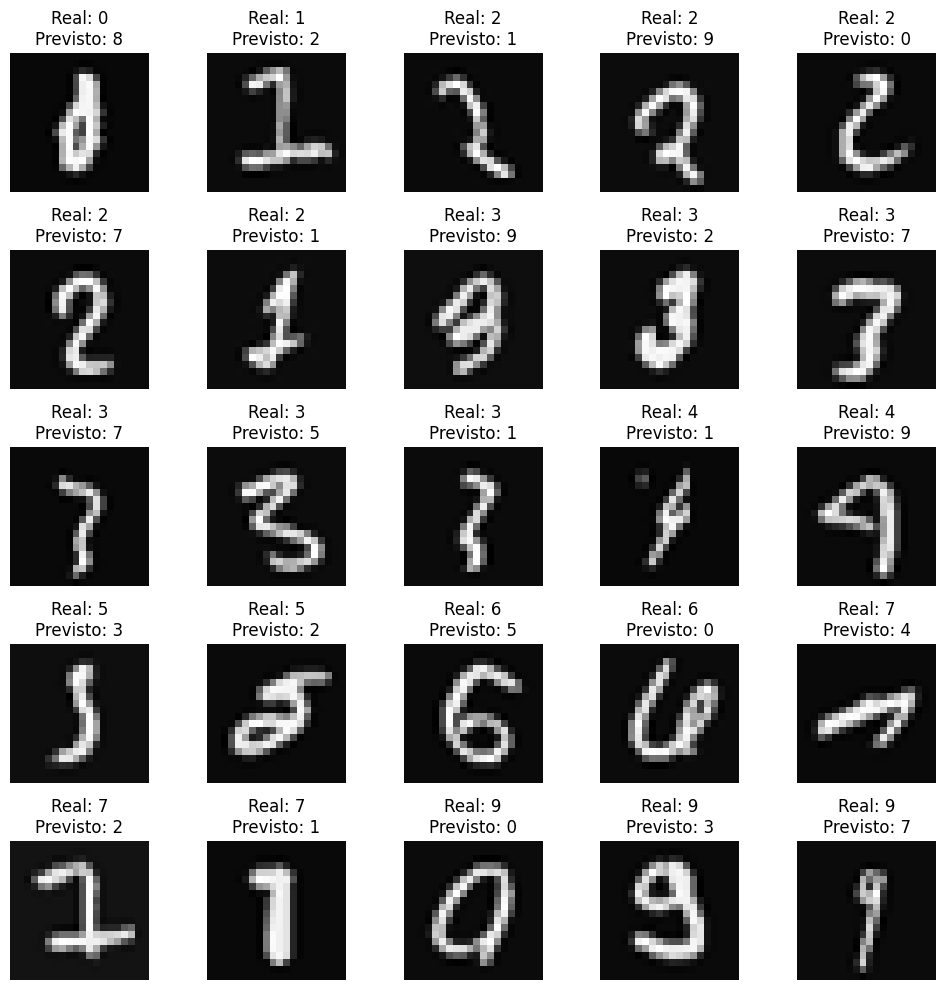

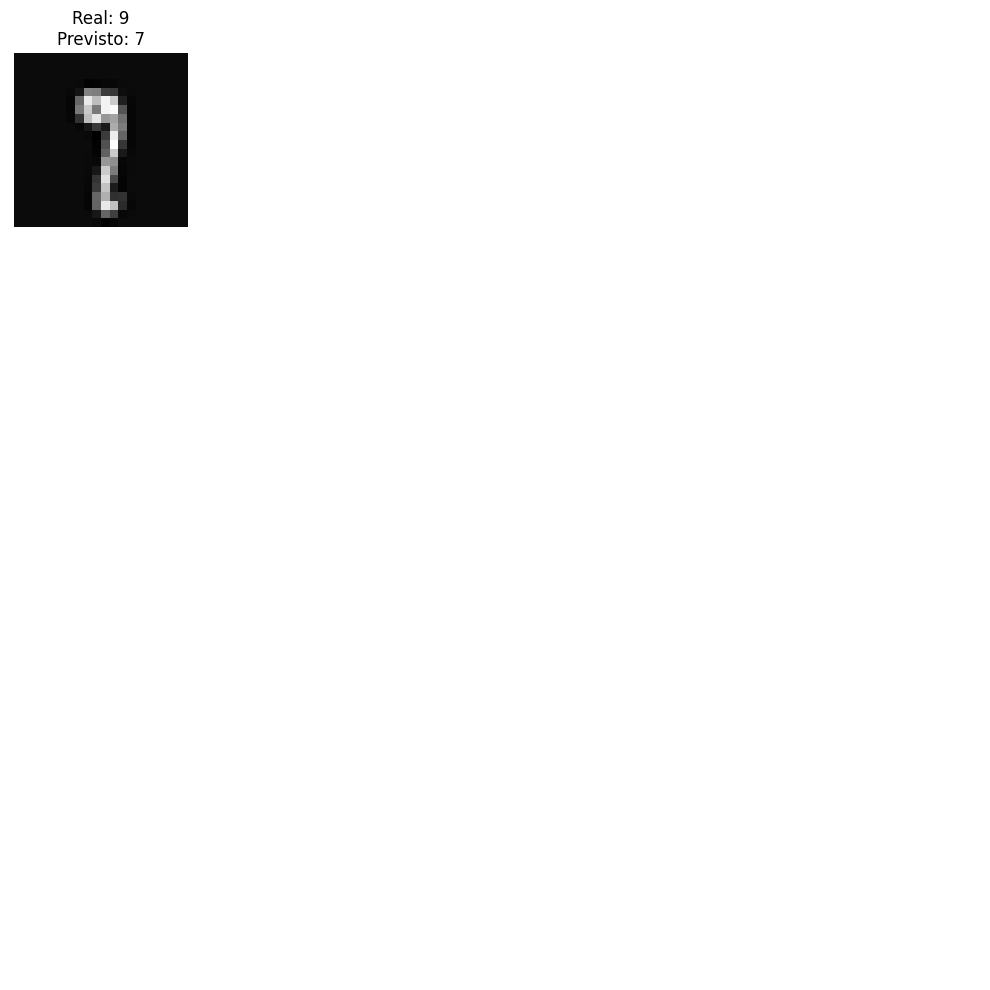

CPU times: user 5min 29s, sys: 496 ms, total: 5min 30s
Wall time: 3min 12s


In [19]:
%%time

lambda_values = [0,1,10]
iteration_values = [100,400]
results_cg = []

for Lambda_cg in lambda_values:
    for max_iter in iteration_values:
        def objective(parameters):
            _,cost,gradient = computeCost(X,y_index,parameters,layer_sizes,Lambda_cg)
            return cost,gradient

        result = minimize(objective,initial_theta.copy(),method="CG",jac=True,
                          options={"maxiter":max_iter,"gtol":1e-5})
        pred_cg = classes[prediction(X,result.x,layer_sizes)]
        accuracy_cg = np.sum(pred_cg == y)/len(y)*100
        results_cg.append((Lambda_cg,max_iter,result,accuracy_cg))
        print(f"Lambda: {Lambda_cg} | Limite: {max_iter} | Iterações: {result.nit} | "
              f"Custo: {result.fun:.6f} | Acurácia: {accuracy_cg:.2f}%")
        print(f"Convergência: {result.success} | {result.message}")

        if Lambda_cg == 1 and max_iter == 400:
            theta_cg = result.x.copy()

pred_cg = classes[prediction(X,theta_cg,layer_sizes)] # Caso de lambda = 1 e max_iter = 400
showWrongImages(X,y,pred_cg,n_show=None)

### Visualização das unidades escondidas

Cada linha da primeira matriz de pesos corresponde a um neurônio da primeira camada escondida. Removemos o bias e reorganizamos os 400 pesos em uma imagem 20 × 20, usando a mesma ordem das imagens de entrada.

A normalização é feita separadamente para cada neurônio: $w_{normalizado}=(w-w_{min})/(w_{max}-w_{min})$. Isso muda apenas a visualização, não os pesos da rede. Se todos os pesos forem iguais, a imagem será preenchida com zeros.

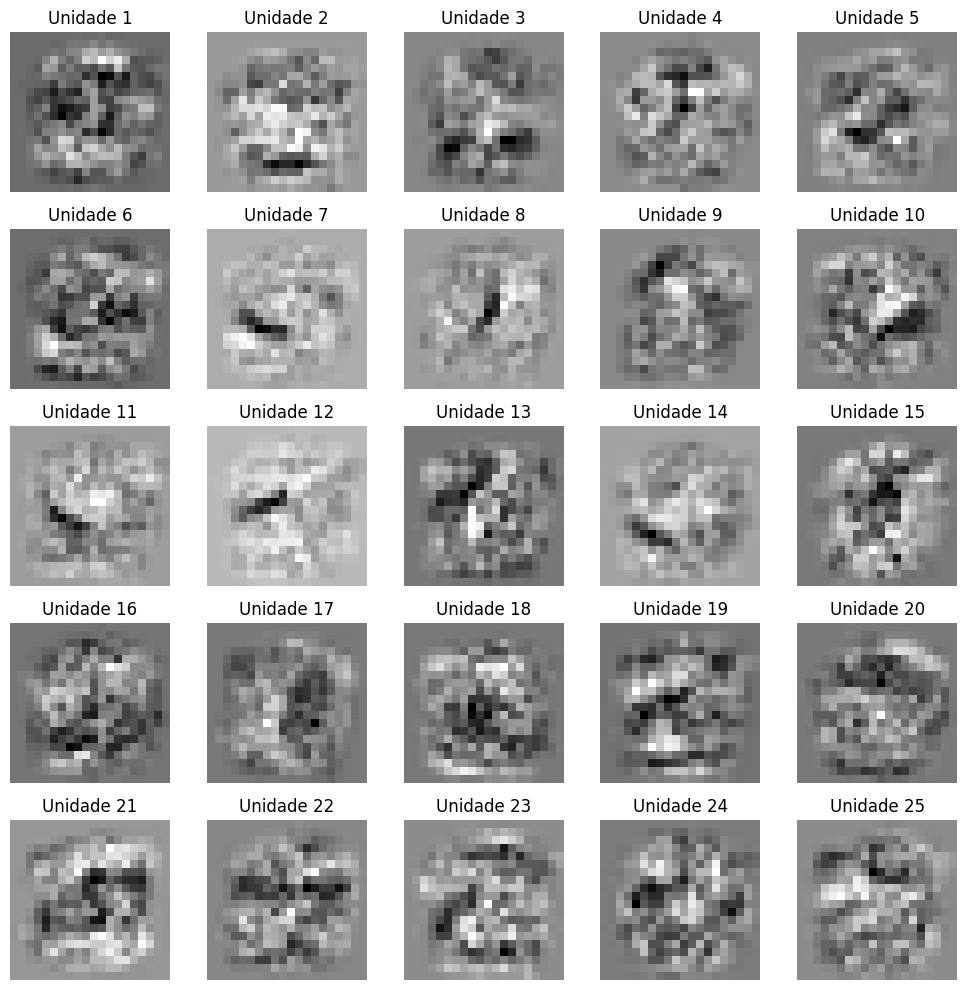

In [20]:
theta1_cg = unpackTheta(theta_cg,layer_sizes)[0]
n_hidden = theta1_cg.shape[0]
n_cols = min(5,n_hidden)
n_rows = (n_hidden+n_cols-1)//n_cols
fig,axes = plt.subplots(n_rows,n_cols,figsize=(2*n_cols,2*n_rows),squeeze=False)
axes = axes.ravel()

for i in range(len(axes)):
    if i < n_hidden:
        weights = theta1_cg[i,1:]
        w_min = np.min(weights)
        w_max = np.max(weights)
        if w_max > w_min:
            weights_scaled = (weights-w_min)/(w_max-w_min)
        else:
            weights_scaled = np.zeros_like(weights)
        axes[i].imshow(weights_scaled.reshape(20,20,order="F"),cmap="gray",vmin=0,vmax=1)
        axes[i].set_title(f"Unidade {i+1}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

### Explicação do código da Parte I

* `layer_sizes` descreve a arquitetura inteira. Por exemplo, `[400,25,10]` tem uma camada escondida; `[400,25,15,10]` tem duas. `initializeTheta` cria os pesos e `unpackTheta` recupera as matrizes a partir de um único vetor.
* Os rótulos originais são associados aos índices de saída `0,1,...,K-1`. `classes` permite converter as previsões de volta aos rótulos. Na base `.mat`, o rótulo 10 é convertido em zero.
* `computeCost` adiciona uma coluna de uns para o bias, calcula as somas ponderadas e aplica a sigmoide em cada camada. A matriz `Y` vale 1 na classe correta e 0 nas demais.
* O custo soma a entropia cruzada das saídas sigmoides e o termo $\lambda/(2m)\sum w^2$, sem penalizar o bias. A expressão com `log1p` é equivalente à entropia cruzada usual, mas evita problemas numéricos quando a sigmoide fica muito próxima de 0 ou 1.
* No `backpropagation`, o erro de saída é `a - Y`. Ele é propagado para trás pelos pesos e multiplicado pela derivada da sigmoide. `delta.T @ a_bias/m` soma as contribuições dos exemplos para cada peso; o gradiente da regularização é somado apenas às colunas que não são bias.
* `gradientDescent` realiza explicitamente a atualização $\theta \leftarrow \theta-\alpha\nabla J$. `J_history` registra o custo inicial e os custos até os pesos finais.
* `prediction` escolhe a saída com maior ativação. A acurácia divide os acertos pelo número real de exemplos; `showWrongImages` mostra os erros em grupos de até 25 imagens.
* `gradient_checking` perturba cada parâmetro em $+\epsilon$ e $-\epsilon$, estimando a derivada por $[J(\theta+\epsilon e_i)-J(\theta-\epsilon e_i)]/(2\epsilon)$. A diferença relativa compara o vetor numérico ao analítico; valores muito menores que $10^{-7}$ indicam boa concordância neste teste. A checagem é feita com e sem regularização.
* No treinamento `CG`, apenas a otimização é delegada ao SciPy, conforme permitido no enunciado. A rede, o custo e o gradiente continuam implementados diretamente. A variação de λ controla a penalização dos pesos; o limite de iterações controla o orçamento de otimização.
* As imagens finais mostram os pesos da primeira camada escondida, normalizados entre 0 e 1. Elas representam padrões aos quais cada unidade responde, não necessariamente um dígito completo.

As funções da rede aceitam diferentes números de exemplos, classes e camadas. As visualizações de imagens são específicas das entradas 20 × 20 desta atividade. O carregamento CSV pressupõe arquivos numéricos sem cabeçalho.

## Parte II — Seleção de Modelo

Nesta etapa, usamos as funções da Parte I para treinar a rede apenas com uma parte dos dados. A validação orienta a escolha de $\lambda$, e o teste mede o desempenho final em exemplos que não participaram do ajuste dos pesos nem da seleção do modelo.

A divisão será de 60% para treino, 20% para validação e 20% para teste. Embaralhamos os índices de cada classe separadamente para manter suas proporções nos três conjuntos.


In [21]:
rng = np.random.default_rng(1)
y = np.asarray(y).ravel()
classes = np.unique(y)
class_to_index = {label: i for i,label in enumerate(classes)}
y_index = np.array([class_to_index[label] for label in y])

train_idx = []
val_idx = []
test_idx = []

for label in classes:
    indices = np.where(y == label)[0]
    rng.shuffle(indices)
    n_train = int(0.6*len(indices))
    n_val = int(0.2*len(indices))
    train_idx.extend(indices[:n_train])
    val_idx.extend(indices[n_train:n_train+n_val])
    test_idx.extend(indices[n_train+n_val:])

train_idx = np.array(train_idx,dtype=int)
val_idx = np.array(val_idx,dtype=int)
test_idx = np.array(test_idx,dtype=int)
rng.shuffle(train_idx)
rng.shuffle(val_idx)
rng.shuffle(test_idx)

X_train,y_train = X[train_idx],y[train_idx]
X_val,y_val = X[val_idx],y[val_idx]
X_test,y_test = X[test_idx],y[test_idx]
y_train_index = y_index[train_idx]
y_val_index = y_index[val_idx]
y_test_index = y_index[test_idx]

print(f"Treino: {len(y_train)} | Validação: {len(y_val)} | Teste: {len(y_test)}")
print("Classe | Treino | Validação | Teste")
for label in classes:
    print(f"{label:6g} | {np.sum(y_train == label):6d} | {np.sum(y_val == label):9d} | {np.sum(y_test == label):5d}")

Treino: 3000 | Validação: 1000 | Teste: 1000
Classe | Treino | Validação | Teste
     0 |    300 |       100 |   100
     1 |    300 |       100 |   100
     2 |    300 |       100 |   100
     3 |    300 |       100 |   100
     4 |    300 |       100 |   100
     5 |    300 |       100 |   100
     6 |    300 |       100 |   100
     7 |    300 |       100 |   100
     8 |    300 |       100 |   100
     9 |    300 |       100 |   100


In [22]:
def trainNetwork(X_data,y_data,initial_params,layer_sizes,Lambda,max_iter):
    def objective(parameters):
        _,cost,gradient = computeCost(X_data,y_data,parameters,layer_sizes,Lambda)
        return cost,gradient

    return minimize(objective,initial_params.copy(),method="CG",jac=True,options={"maxiter":max_iter,"gtol":1e-5})


def evaluateNetwork(X_data,y_data,parameters,layer_sizes):
    cost = computeCost(X_data,y_data,parameters,layer_sizes,0)[0]
    pred_index = prediction(X_data,parameters,layer_sizes)
    error = np.sum(pred_index != y_data)/len(y_data)*100
    return cost,error


hidden_layer_sizes_II = [25]
layer_sizes_II = [X.shape[1]] + hidden_layer_sizes_II + [len(classes)]
np.random.seed(2)
initial_theta_II = initializeTheta(layer_sizes_II)
max_iter_II = 400
Lambda_base = 1

result_base = trainNetwork(X_train,y_train_index,initial_theta_II,layer_sizes_II,Lambda_base,max_iter_II)
theta_base = result_base.x.copy()

for name,X_data,y_data in [("Treino",X_train,y_train_index),("Validação",X_val,y_val_index)]:
    cost,error = evaluateNetwork(X_data,y_data,theta_base,layer_sizes_II)
    print(f"{name}: custo = {cost:.6f} | Erro = {error:.2f}% | Acurácia = {100-error:.2f}%")
print(f"Iterações: {result_base.nit} | Convergência: {result_base.success}")
print(result_base.message)

Treino: custo = 0.144472 | Erro = 0.33% | Acurácia = 99.67%
Validação: custo = 0.476619 | Erro = 7.00% | Acurácia = 93.00%
Iterações: 400 | Convergência: False
Maximum number of iterations has been exceeded.


### Curva de aprendizado

Para cada tamanho $m$, treinamos uma nova rede com os primeiros $m$ exemplos do conjunto de treino já embaralhado. Os subconjuntos são crescentes: cada um contém os exemplos do anterior. Calculamos o custo sobre esse subconjunto e sobre todo o conjunto de validação.

Mantemos $\lambda=1$, a arquitetura, os pesos iniciais e o limite de iterações fixos. O gráfico usa os custos sem regularização. Cada ponto exige um treinamento próprio.

Custos altos e próximos podem indicar underfitting; custo de treino baixo e de validação mais alto pode indicar overfitting. Essas interpretações também dependem de o treinamento ter avançado suficientemente.

m =  100 | Treino: 0.621301 | Validação: 1.482846 | Iterações: 331 | Convergência: True
m =  422 | Treino: 0.292982 | Validação: 0.837530 | Iterações: 400 | Convergência: False
m =  744 | Treino: 0.216690 | Validação: 0.707036 | Iterações: 400 | Convergência: False
m = 1066 | Treino: 0.188741 | Validação: 0.612829 | Iterações: 400 | Convergência: False
m = 1388 | Treino: 0.170846 | Validação: 0.578410 | Iterações: 400 | Convergência: False
m = 1711 | Treino: 0.159491 | Validação: 0.537327 | Iterações: 400 | Convergência: False
m = 2033 | Treino: 0.158070 | Validação: 0.532583 | Iterações: 400 | Convergência: False
m = 2355 | Treino: 0.150908 | Validação: 0.507340 | Iterações: 400 | Convergência: False
m = 2677 | Treino: 0.143183 | Validação: 0.479772 | Iterações: 400 | Convergência: False
m = 3000 | Treino: 0.144472 | Validação: 0.476619 | Iterações: 400 | Convergência: False


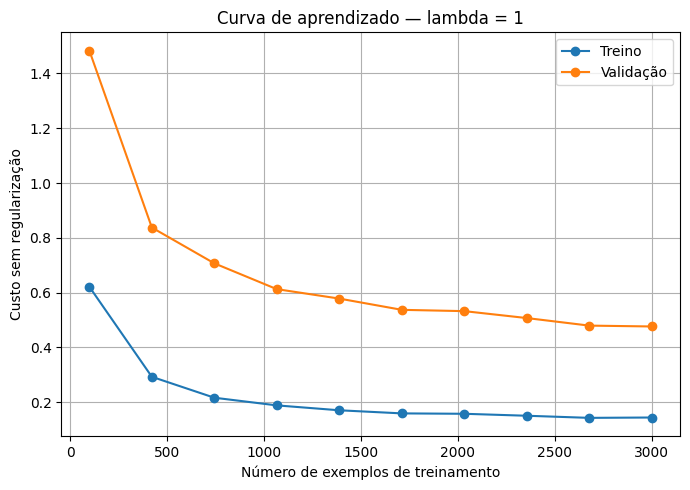

In [23]:
train_sizes = np.unique(np.linspace(min(100,len(y_train)),len(y_train),10,dtype=int))
train_errors = []
val_errors = []
learning_results = []

for size in train_sizes:
    result_learning = trainNetwork(X_train[:size],y_train_index[:size],initial_theta_II,layer_sizes_II,Lambda_base,max_iter_II)
    train_cost,_ = evaluateNetwork(X_train[:size],y_train_index[:size],result_learning.x,layer_sizes_II)
    val_cost,_ = evaluateNetwork(X_val,y_val_index,result_learning.x,layer_sizes_II)
    train_errors.append(train_cost)
    val_errors.append(val_cost)
    learning_results.append(result_learning)
    print(f"m = {size:4d} | Treino: {train_cost:.6f} | Validação: {val_cost:.6f} | Iterações: {result_learning.nit} | Convergência: {result_learning.success}")

plt.figure(figsize=(7,5))
plt.plot(train_sizes,train_errors,"o-",label="Treino")
plt.plot(train_sizes,val_errors,"o-",label="Validação")
plt.xlabel("Número de exemplos de treinamento")
plt.ylabel("Custo sem regularização")
plt.title("Curva de aprendizado — lambda = 1")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

### Escolha do parâmetro de regularização

Testamos os valores sugeridos no enunciado:

$$
\lambda\in\{0;\ 0{,}001;\ 0{,}003;\ 0{,}01;\ 0{,}03;\ 0{,}1;\ 0{,}3;\ 1;\ 3;\ 10\}.
$$

Para cada valor, treinamos somente com `X_train` e escolhemos aquele com menor custo de validação sem regularização. Em caso de empate exato, mantemos o primeiro valor encontrado. O conjunto de teste não participa dessa escolha.


Lambda = 0 | Treino: 0.000412 | Validação: 1.069702 | Iterações: 210 | Convergência: True
Lambda = 0.001 | Treino: 0.000558 | Validação: 1.015357 | Iterações: 181 | Convergência: True
Lambda = 0.003 | Treino: 0.000879 | Validação: 0.974482 | Iterações: 178 | Convergência: True
Lambda = 0.01 | Treino: 0.002521 | Validação: 0.725584 | Iterações: 400 | Convergência: False
Lambda = 0.03 | Treino: 0.006526 | Validação: 0.661576 | Iterações: 400 | Convergência: False
Lambda = 0.1 | Treino: 0.018395 | Validação: 0.578056 | Iterações: 400 | Convergência: False
Lambda = 0.3 | Treino: 0.050683 | Validação: 0.506196 | Iterações: 400 | Convergência: False
Lambda = 1 | Treino: 0.144472 | Validação: 0.476619 | Iterações: 400 | Convergência: False
Lambda = 3 | Treino: 0.333112 | Validação: 0.510962 | Iterações: 400 | Convergência: False
Lambda = 10 | Treino: 0.680281 | Validação: 0.759881 | Iterações: 400 | Convergência: False

Lambda escolhido: 1


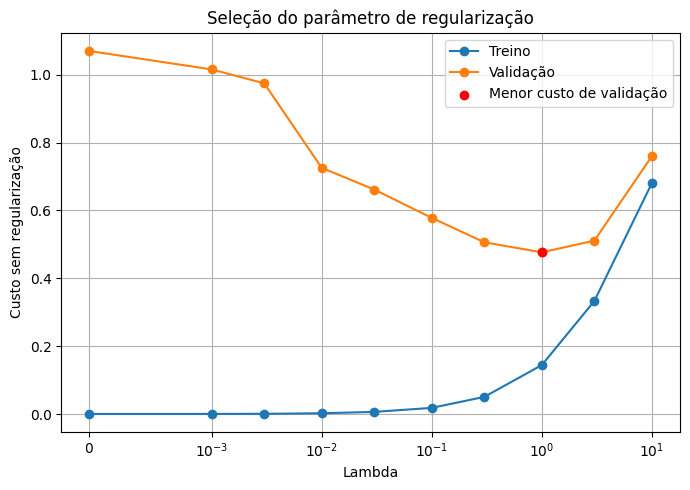

In [24]:
lambda_values_II = [0,0.001,0.003,0.01,0.03,0.1,0.3,1,3,10]
train_costs_lambda = []
val_costs_lambda = []
results_lambda = []
best_val_cost = float("inf")
best_index = None

for i,Lambda_value in enumerate(lambda_values_II):
    result_lambda = trainNetwork(X_train,y_train_index,initial_theta_II,layer_sizes_II,Lambda_value,max_iter_II)
    train_cost,_ = evaluateNetwork(X_train,y_train_index,result_lambda.x,layer_sizes_II)
    val_cost,_ = evaluateNetwork(X_val,y_val_index,result_lambda.x,layer_sizes_II)
    train_costs_lambda.append(train_cost)
    val_costs_lambda.append(val_cost)
    results_lambda.append(result_lambda)

    if val_cost < best_val_cost:
        best_val_cost = val_cost
        best_index = i

    print(f"Lambda = {Lambda_value:g} | Treino: {train_cost:.6f} | Validação: {val_cost:.6f} | Iterações: {result_lambda.nit} | Convergência: {result_lambda.success}")

best_lambda = lambda_values_II[best_index]
theta_best = results_lambda[best_index].x.copy()
print(f"\nLambda escolhido: {best_lambda:g}")

plt.figure(figsize=(7,5))
plt.plot(lambda_values_II,train_costs_lambda,"o-",label="Treino")
plt.plot(lambda_values_II,val_costs_lambda,"o-",label="Validação")
plt.scatter([best_lambda],[best_val_cost],color="red",zorder=3,label="Menor custo de validação")
plt.xscale("symlog",linthresh=0.001)
plt.xlabel("Lambda")
plt.ylabel("Custo sem regularização")
plt.title("Seleção do parâmetro de regularização")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

### Avaliação final no conjunto de teste

Com $\lambda$ escolhido, avaliamos a rede selecionada nos três conjuntos. Os resultados de teste são apresentados somente nesta etapa e não participam da escolha de $\lambda$.

In [25]:
final_metrics = []
model_name = f"Rede selecionada (lambda = {best_lambda:g})"

print(model_name)

for name,X_data,y_data in [("Treino",X_train,y_train_index),("Validação",X_val,y_val_index),("Teste",X_test,y_test_index)]:
    cost,error = evaluateNetwork(X_data,y_data,theta_best,layer_sizes_II)
    final_metrics.append((model_name,name,cost,error))

    print(f"{name}: custo = {cost:.6f} | Erro = {error:.2f}% | Acurácia = {100-error:.2f}%")

Rede selecionada (lambda = 1)
Treino: custo = 0.144472 | Erro = 0.33% | Acurácia = 99.67%
Validação: custo = 0.476619 | Erro = 7.00% | Acurácia = 93.00%
Teste: custo = 0.477752 | Erro = 6.30% | Acurácia = 93.70%


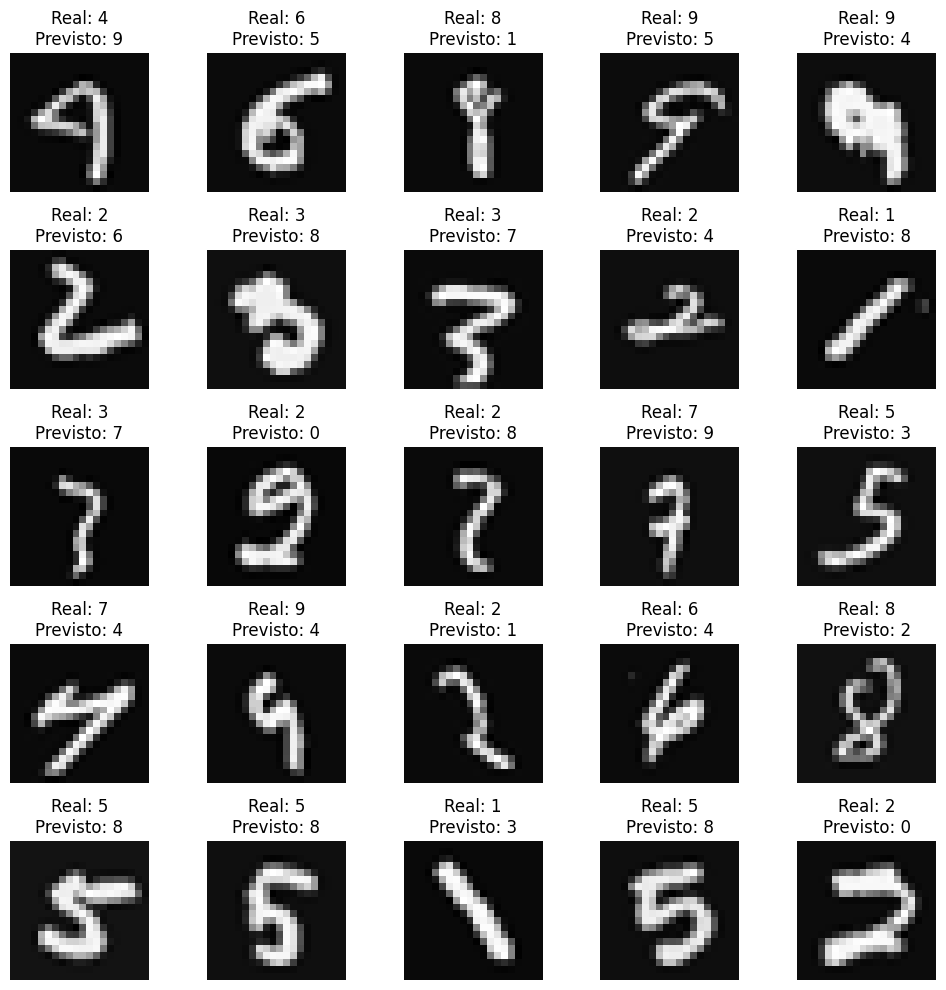

In [26]:
pred_test = classes[prediction(X_test,theta_best,layer_sizes_II)]
showWrongImages(X_test,y_test,pred_test,n_show=25)

### Comentários sobre os resultados

O menor custo de validação foi obtido com $\lambda=1$, coincidindo com o valor utilizado na rede inicial. Por isso, apresentamos apenas uma avaliação final do modelo selecionado.

| Conjunto | Custo sem regularização | Erro de classificação | Acurácia |
|---|---:|---:|---:|
| Treino | 0,144472 | 0,33% | 99,67% |
| Validação | 0,476619 | 7,00% | 93,00% |
| Teste | 0,477752 | 6,30% | 93,70% |

No conjunto de teste, a rede classificou corretamente 937 das 1.000 imagens, cometendo 63 erros. Os custos de validação e teste ficaram próximos, enquanto o custo de treino foi menor. Isso mostra um desempenho inferior nos exemplos não utilizados para ajustar os pesos, embora a regularização tenha reduzido essa diferença em comparação ao modelo sem penalização.

Com $\lambda=0$, o custo de treino foi 0,000412, mas o custo de validação foi 1,069702. Esse contraste indica overfitting: o modelo ajustou muito bem os exemplos de treinamento, mas apresentou desempenho pior na validação. Com $\lambda=1$, o custo de validação caiu para 0,476619. Aumentar a regularização para $\lambda=10$ elevou os custos de treino e validação para 0,680281 e 0,759881, respectivamente, sugerindo uma penalização excessiva para essa configuração.

A escolha de $\lambda$ foi feita pelo menor custo de validação sem regularização. O termo de regularização foi utilizado no treinamento, mas não somado às métricas de avaliação. O conjunto de teste foi utilizado somente após essa escolha.

Na curva de aprendizado, o custo de validação diminuiu de 1,482846 com 100 exemplos para 0,476619 com 3.000 exemplos, mostrando o benefício de aumentar o conjunto de treinamento. O custo de treino também diminuiu de modo geral, passando de 0,621301 para 0,144472. Esse comportamento pode ser influenciado pelo fator $\lambda/m$: mantendo $\lambda$ fixo, a influência relativa da regularização diminui conforme o número de exemplos aumenta.

O treinamento com 100 exemplos convergiu após 331 iterações, mesmo apresentando custo de validação maior. Convergência significa que o critério de parada da otimização foi satisfeito; não significa que o modelo tenha baixo custo ou boa capacidade de generalização.

Os demais pontos da curva de aprendizado e o modelo selecionado atingiram o limite de 400 iterações sem satisfazer a tolerância do gradiente. Portanto, os resultados correspondem a esse limite de treinamento e não garantem convergência de todos os modelos. Outro limite de iterações ou outra inicialização pode alterar os resultados e o valor de $\lambda$ selecionado.
